In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# Dataset Exploration:

In [358]:
df=pd.read_csv("Expanded_data_with_more_features.csv")

In [359]:
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [360]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [361]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [362]:
df. columns

Index(['Unnamed: 0', 'Gender', 'EthnicGroup', 'ParentEduc', 'LunchType',
       'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild',
       'NrSiblings', 'TransportMeans', 'WklyStudyHours', 'MathScore',
       'ReadingScore', 'WritingScore'],
      dtype='object')

In [363]:
df.drop(columns="Unnamed: 0",inplace=True)

In [364]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


# Handling Missing Values

In [366]:
df.isnull().sum()

Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

### Imputation nulls values

In [367]:
nums_cols=["NrSiblings","MathScore","ReadingScore","WritingScore"]
for i in nums_cols:
    df[i].fillna(df[i].mean(),inplace=True)
cat_cols=['Gender',"EthnicGroup","ParentEduc","LunchType","TestPrep","ParentMaritalStatus","PracticeSport","WklyStudyHours","IsFirstChild","TransportMeans"]
for j in cat_cols:
    df[j].fillna(df[j].mode()[0],inplace=True)

In [368]:
df.isnull().sum()

Gender                 0
EthnicGroup            0
ParentEduc             0
LunchType              0
TestPrep               0
ParentMaritalStatus    0
PracticeSport          0
IsFirstChild           0
NrSiblings             0
TransportMeans         0
WklyStudyHours         0
MathScore              0
ReadingScore           0
WritingScore           0
dtype: int64

## check Duplicated

In [369]:
df.duplicated().sum()

np.int64(1)

In [370]:
df = df.drop_duplicates()

In [371]:
df.duplicated().sum()

np.int64(0)

# Encoding cats cols

In [372]:
from sklearn.preprocessing import LabelEncoder

In [373]:
le=LabelEncoder()  # call

In [374]:

for k in cat_cols:
    df[k] = le.fit_transform(df[k])
    

In [375]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,2,1,1,1,1,1,1,3.0,1,1,71,71,74
1,0,2,4,1,1,1,2,1,0.0,1,0,69,90,88
2,0,1,3,1,1,2,2,1,4.0,1,1,87,93,91
3,1,0,0,0,1,1,0,0,1.0,1,0,45,56,42
4,1,2,4,1,1,1,2,1,0.0,1,0,76,78,75


# Explore and address outliers 

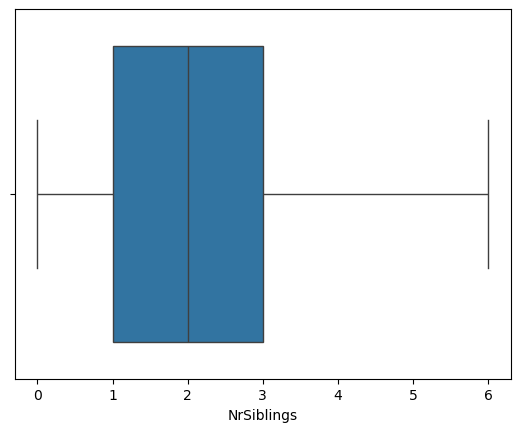

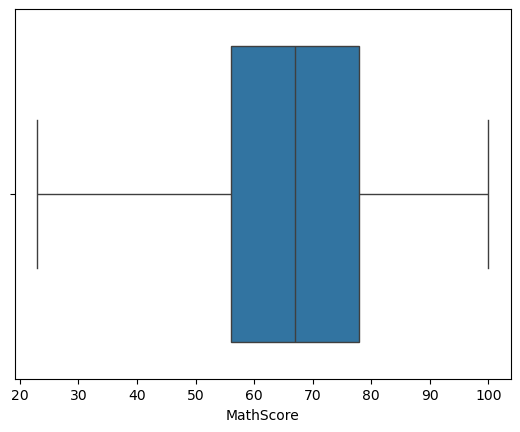

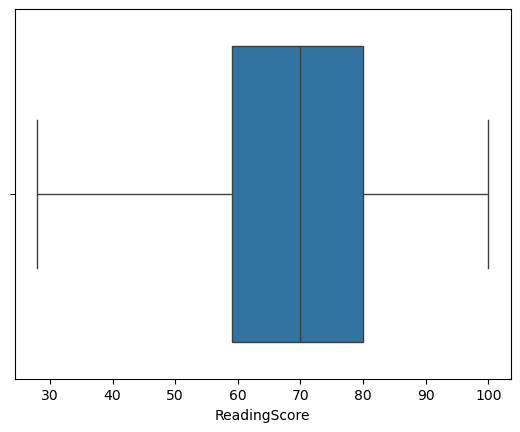

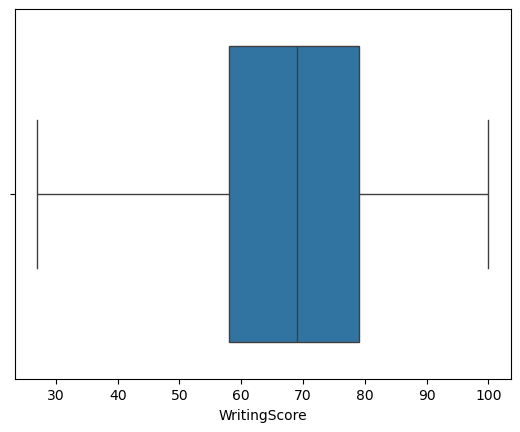

In [376]:
for h in nums_cols:
    Q1 = df[h].quantile(0.25)
    Q3 = df[h].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[h] >= Q1 - 1.5*IQR) & (df[h] <= Q3 + 1.5*IQR)]
    sns.boxplot(x=df[h])
    plt.show()


# EDA->Exploratory Data Analysis

### Visualize the distribution of the target variable.

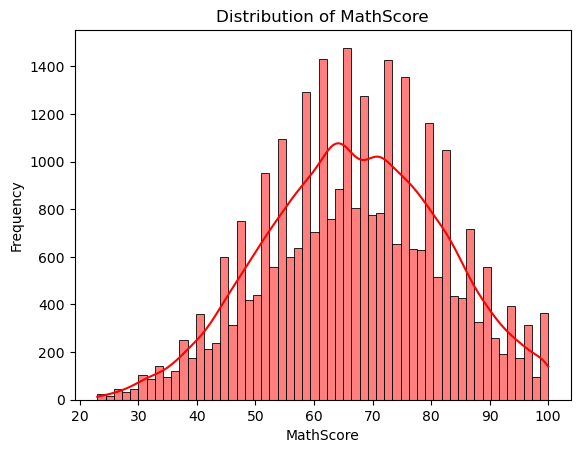

In [377]:
sns.histplot(df["MathScore"],kde=True,color="red")
plt.title("Distribution of MathScore")
plt.xlabel("MathScore")
plt.ylabel("Frequency")
plt.show()

### Examine the relationships between features and the target through pair plots


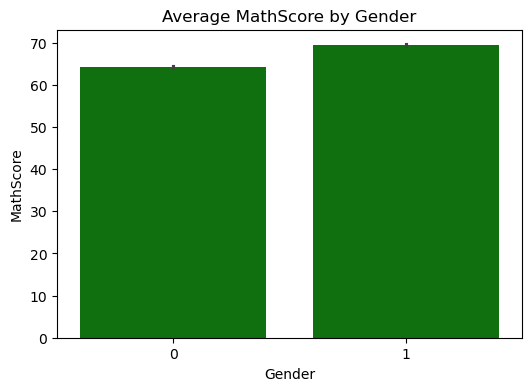

In [378]:
plt.figure(figsize=(6,4))
sns.barplot(x="Gender", y="MathScore", data=df,color="green")
plt.title("Average MathScore by Gender")
plt.show()

In [379]:
y=df['MathScore']
x=df.drop(columns='MathScore')

# Train-Test Split

### Split the dataset into training and testing sets

In [380]:
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2, random_state=42)

In [381]:
print("Training set shape:", x_train.shape, y_train.shape)
print("Testing set shape:", x_test.shape, y_test.shape)

Training set shape: (24147, 13) (24147,)
Testing set shape: (6037, 13) (6037,)


# Feature Scaling

### Apply feature scaling if needed to ensure that all features are on a similar scale. 

In [382]:
from sklearn.preprocessing import StandardScaler


In [383]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled = scaler.transform(x_test) 

# Linear Regression Model: 

### Build a linear regression model using a suitable library 

In [384]:
model=LinearRegression()

### Train the model on the training dataset

In [385]:
model.fit(x_train_scaled, y_train)

LinearRegression()

# Model Evaluation

### Evaluate the model's performance on the testing set

In [386]:
from sklearn.metrics import mean_squared_error, r2_score

In [387]:
y_pred=model.predict(x_test_scaled)

In [388]:
mse=mean_squared_error(y_test,y_pred)

In [389]:
r2 = r2_score(y_test, y_pred)

In [390]:
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 31.884386901145707
R-squared: 0.8607903368267148


# Visualization

### Visualize the predicted values against the actual values using scatter plots or regression plots


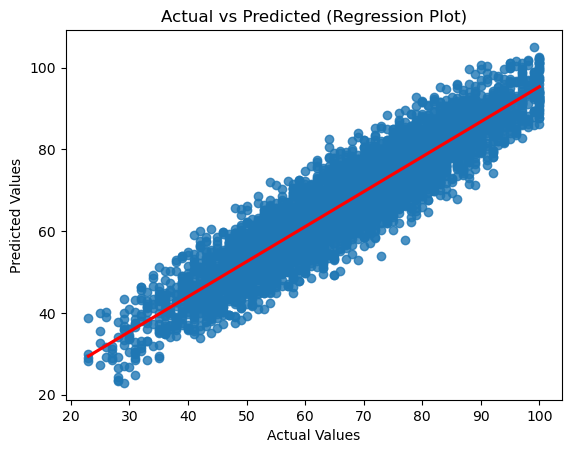

In [391]:

sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Regression Plot)")
plt.show()


## Conclusion


#### Summarize the findings from the linear regression task
The Linear Regression model achieved an R-squared value of **0.86**, which means it explains about **86%** of the variance in Math scores.  
The Mean Squared Error (**31.88**) indicates that the prediction error is relatively low.  
Overall, the model provides good performance and accurate predictions

## Reflection

The Linear Regression model performed well, achieving an R-squared value of **0.86**, which shows that it explains most of the variance in Math scores.  
The relatively low MSE also indicates accurate predictions.  

However, the model could be improved by:
- Adding more relevant features to capture additional factors affecting Math scores,  
- Comparing performance with other regression models such as Random Forest or Gradient Boosting.
